# wandas skill validation

This notebook validates that the documented wandas skills map to working APIs in this repository.

Skills covered:
- wandas-getting-started
- wandas-signal-processing
- wandas-spectral-analysis
- wandas-visualization

In [1]:
from pathlib import Path



import matplotlib.pyplot as plt

import wandas as wd



plt.rcParams['figure.figsize'] = (10, 4)

cwd = Path.cwd().resolve()

project_root = cwd if (cwd / 'wandas').exists() else cwd.parent

csv_path = project_root / 'learning-path' / 'sensor_data.csv'

assert csv_path.exists(), csv_path


## 0. Skill file loading check

Confirm that the restored Claude skill files are present on disk and readable from the notebook.


In [2]:
skill_root = project_root / '.claude' / 'skills'

skill_paths = {

    'wandas-getting-started': skill_root / 'wandas-getting-started' / 'SKILL.md',

    'wandas-signal-processing': skill_root / 'wandas-signal-processing' / 'SKILL.md',

    'wandas-spectral-analysis': skill_root / 'wandas-spectral-analysis' / 'SKILL.md',

    'wandas-visualization': skill_root / 'wandas-visualization' / 'SKILL.md',

}



skill_descriptions = {}

for skill_name, skill_path in skill_paths.items():

    assert skill_path.exists(), skill_path

    content = skill_path.read_text(encoding='utf-8')

    assert content.startswith('---\nname:'), skill_name

    description_line = next(

        line for line in content.splitlines() if line.startswith('description:')

    )

    skill_descriptions[skill_name] = description_line.removeprefix('description:').strip()



print('Restored skill files loaded successfully:')

for skill_name, description in skill_descriptions.items():

    print(f'- {skill_name}: {description}')



assert len(skill_descriptions) == 4


Restored skill files loaded successfully:
- wandas-getting-started: Use when starting with the wandas library, loading audio or sensor data from WAV or CSV files, creating signals from NumPy arrays, understanding ChannelFrame and other frame types, or needing a quick overview of wandas I/O and inspection functions.
- wandas-signal-processing: Use when applying filters (lowpass, highpass, bandpass, A-weighting), normalizing signals, resampling, trimming, adding fades, computing RMS trends, or separating harmonic and percussive components with wandas.
- wandas-spectral-analysis: Use when performing FFT, STFT, Welch PSD estimation, octave band analysis, coherence, cross-spectral density, or transfer function analysis with wandas.
- wandas-visualization: Use when plotting waveforms, frequency spectra, spectrograms, or octave band charts with wandas, overlaying multiple signals on the same axes, or configuring describe() with frequency range and colormap settings.


## 1. Getting started skill
Validate `generate_sin` and `read_csv`, plus basic frame inspection properties.

In [3]:
signal = wd.generate_sin(freqs=[440, 880], sampling_rate=8000, duration=0.5, label='Skill Validation Signal')
sensor = wd.read_csv(str(csv_path), time_column='time')

print('signal labels:', signal.labels)
print('signal sampling rate:', signal.sampling_rate)
print('signal duration:', signal.duration)
print('sensor shape:', sensor.shape)
print('sensor labels:', sensor.labels)

assert signal.n_channels == 2
assert signal.sampling_rate == 8000
assert round(signal.duration, 3) == 0.5
assert sensor.n_channels >= 1
assert sensor.duration > 0

signal labels: ['Channel 1', 'Channel 2']
signal sampling rate: 8000
signal duration: 0.5
sensor shape: (4, 6000)
sensor labels: ['accel_x', 'accel_y', 'accel_z', 'temperature']


## 2. Signal processing skill
Validate chaining with `high_pass_filter`, `low_pass_filter`, `normalize`, and `fade`.

In [4]:
processed = (
    signal
    .high_pass_filter(cutoff=100)
    .low_pass_filter(cutoff=1200)
    .normalize()
    .fade(fade_ms=10)
)

print('operation history entries:', len(processed.operation_history))
print('latest operations:', [entry['operation'] for entry in processed.operation_history[-4:]])

assert processed is not signal
assert len(processed.operation_history) >= len(signal.operation_history) + 4

operation history entries: 4
latest operations: ['highpass_filter', 'lowpass_filter', 'normalize', 'fade']


## 3. Spectral analysis skill
Validate `fft` and `stft`, and check resulting frame metadata.

In [5]:
spectrum = processed.fft(n_fft=1024)
spectrogram = processed.stft(n_fft=256, hop_length=64, window='hann')

print('first frequency bins:', spectrum.freqs[:5])
print('spectrum shape:', spectrum.shape)
print('spectrogram shape:', spectrogram.shape)

assert spectrum.shape[-1] > 0
assert len(spectrum.freqs) == spectrum.shape[-1]
assert spectrogram.shape[-1] > 0

first frequency bins: [ 0.      7.8125 15.625  23.4375 31.25  ]
spectrum shape: (2, 513)
spectrogram shape: (2, 129, 66)


## 4. Visualization skill
Validate `plot` and `describe` return/display behavior without relying on manual inspection only.

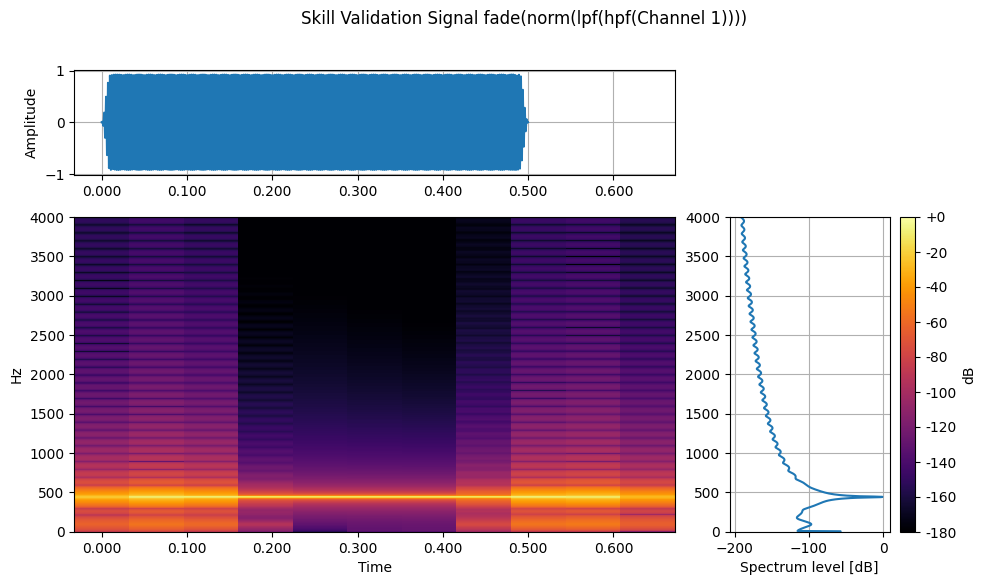

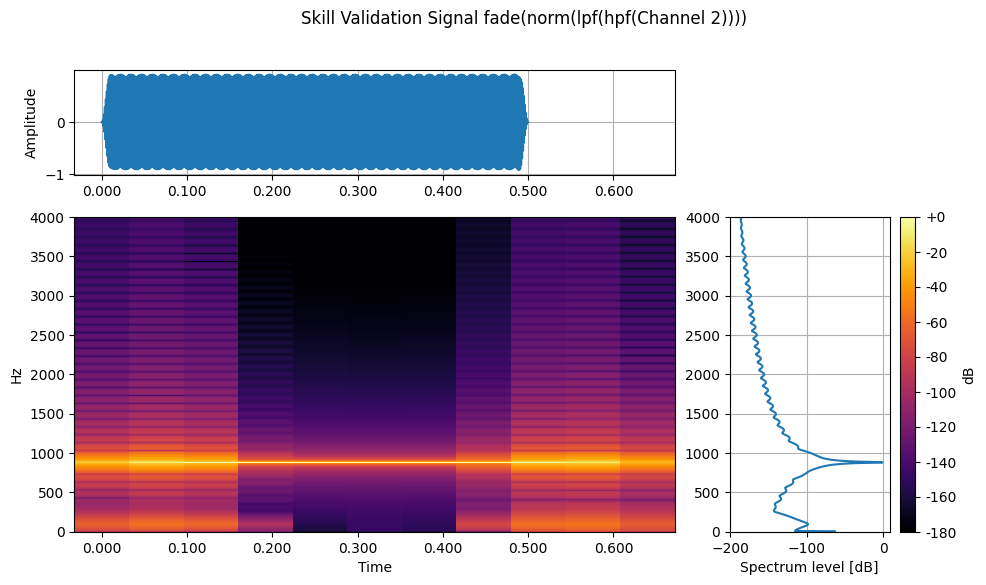

Visualization APIs returned expected matplotlib objects.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

wave_ax = processed.plot(ax=axes[0], overlay=True, title='Processed waveform')

spec_ax = spectrum.plot(ax=axes[1], overlay=True, title='FFT spectrum')

single_channel_spectrogram = processed[0].stft(n_fft=256, hop_length=64, window='hann')

stft_ax = single_channel_spectrogram.plot(ax=axes[2], cmap='inferno', title='Single-channel STFT spectrogram')

plt.tight_layout()



figures = processed.describe(

    is_close=False,

    normalize=False,

    fmin=0,

    fmax=2000,

    cmap='inferno',

)



assert wave_ax is axes[0]

assert spec_ax is axes[1]

assert stft_ax is axes[2]

assert figures is not None

assert len(figures) == processed.n_channels



plt.close(fig)

for figure in figures:

    plt.close(figure)



print('Visualization APIs returned expected matplotlib objects.')


## 5. Combined skill scenario: make a hidden fault visible
Build a realistic vibration-monitoring scenario by combining multiple skills on the same signal.

Scenario:
- Start from the real accelerometer channel in `sensor_data.csv`
- Inject a slow drift plus a short-lived 38 Hz bearing resonance
- Use processing + spectral analysis + visualization together to reveal when and where the fault appears

Success criteria:
- The raw waveform alone does not explain the issue clearly
- The conditioned spectrum highlights the 38 Hz band
- The RMS trend localizes the event in time
- The STFT makes the transient resonance visible

38 Hz band gain ratio: 3.89
RMS peak time [s]: 24.32
Combined skills used: getting-started + signal-processing + spectral-analysis + visualization


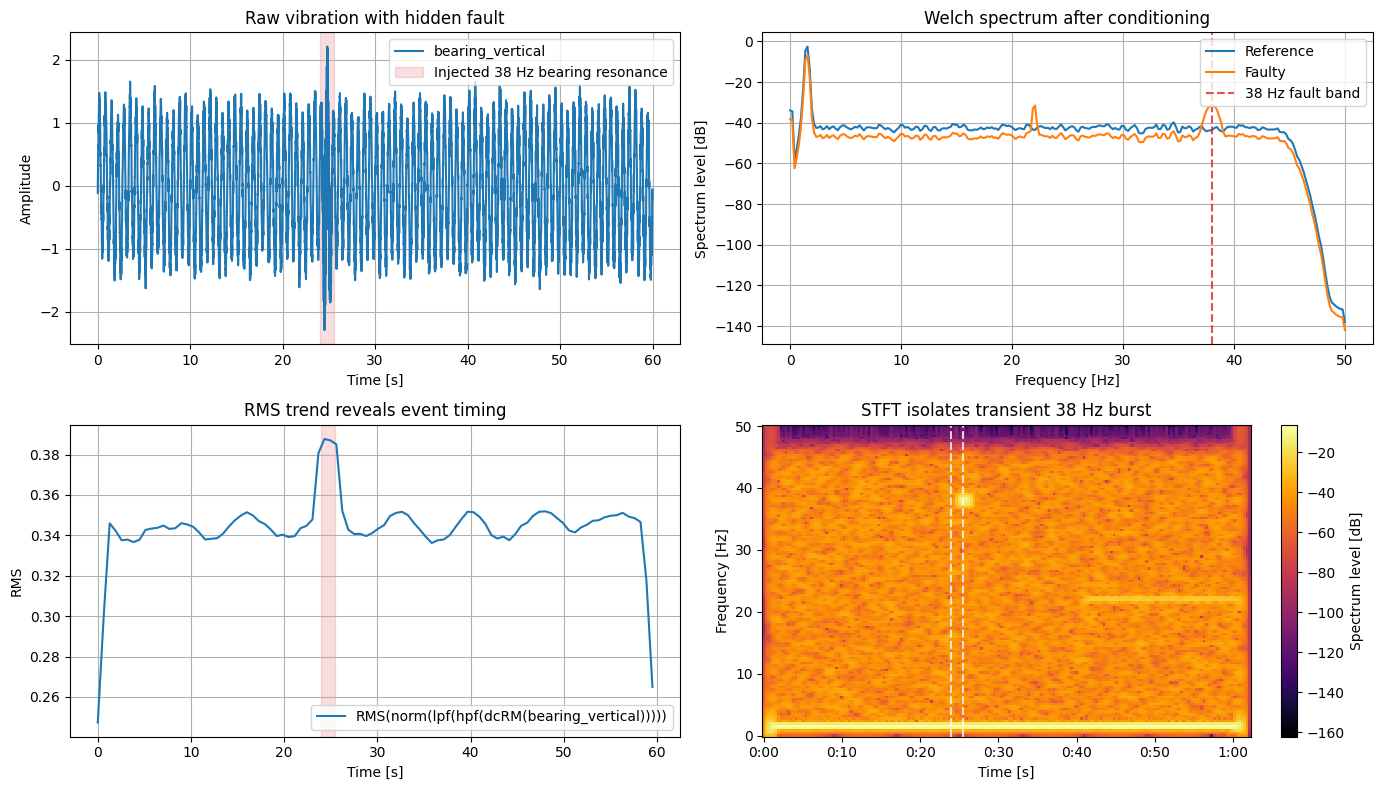

In [7]:
import numpy as np

baseline_array = np.asarray(sensor['accel_y'].compute().data).reshape(-1)
sampling_rate = int(round(sensor.sampling_rate))
time = np.arange(baseline_array.size) / sampling_rate

fault_start = 24.0
fault_end = 25.5
fault_envelope = np.zeros_like(time)
fault_region = (time >= fault_start) & (time <= fault_end)
fault_envelope[fault_region] = np.hanning(fault_region.sum())

faulty_array = (
    baseline_array
    + 0.18 * np.sin(2 * np.pi * 0.35 * time)
    + 1.2 * np.sin(2 * np.pi * 38 * time) * fault_envelope
    + 0.12 * np.sin(2 * np.pi * 22 * time) * (time >= 40.0)
)

reference_signal = wd.from_numpy(
    baseline_array,
    sampling_rate=sampling_rate,
    label='Reference machine state',
    ch_labels=['bearing_vertical'],
)
faulty_signal = wd.from_numpy(
    faulty_array,
    sampling_rate=sampling_rate,
    label='Faulty machine state',
    ch_labels=['bearing_vertical'],
)

focused_reference = (
    reference_signal
    .remove_dc()
    .high_pass_filter(cutoff=1.0)
    .low_pass_filter(cutoff=45.0)
    .normalize()
)
focused_faulty = (
    faulty_signal
    .remove_dc()
    .high_pass_filter(cutoff=1.0)
    .low_pass_filter(cutoff=45.0)
    .normalize()
)

trend = focused_faulty.rms_trend(frame_length=256, hop_length=64, dB=False)
reference_psd = focused_reference.welch(n_fft=512, hop_length=128)
faulty_psd = focused_faulty.welch(n_fft=512, hop_length=128)
faulty_spec = focused_faulty.stft(n_fft=256, hop_length=32, window='hann')

scenario_fig, scenario_axes = plt.subplots(2, 2, figsize=(14, 8))

faulty_signal.plot(
    ax=scenario_axes[0, 0],
    title='Raw vibration with hidden fault',
    overlay=True,
)
scenario_axes[0, 0].axvspan(
    fault_start,
    fault_end,
    color='tab:red',
    alpha=0.15,
    label='Injected 38 Hz bearing resonance',
)
scenario_axes[0, 0].legend(loc='upper right')

reference_psd.plot(ax=scenario_axes[0, 1], overlay=True, label='Reference')
faulty_psd.plot(
    ax=scenario_axes[0, 1],
    overlay=True,
    label='Faulty',
    title='Welch spectrum after conditioning',
)
scenario_axes[0, 1].axvline(
    38,
    color='tab:red',
    linestyle='--',
    alpha=0.8,
    label='38 Hz fault band',
)
scenario_axes[0, 1].legend(loc='upper right')

trend.plot(
    ax=scenario_axes[1, 0],
    title='RMS trend reveals event timing',
    overlay=True,
    ylabel='RMS',
)
scenario_axes[1, 0].axvspan(fault_start, fault_end, color='tab:red', alpha=0.15)

faulty_spec.plot(
    ax=scenario_axes[1, 1],
    cmap='inferno',
    title='STFT isolates transient 38 Hz burst',
)
scenario_axes[1, 1].axvline(fault_start, color='white', linestyle='--', alpha=0.8)
scenario_axes[1, 1].axvline(fault_end, color='white', linestyle='--', alpha=0.8)

plt.tight_layout()

reference_psd_array = np.asarray(reference_psd.compute().data).reshape(-1)
faulty_psd_array = np.asarray(faulty_psd.compute().data).reshape(-1)
trend_array = np.asarray(trend.compute().data).reshape(-1)
freqs = reference_psd.freqs

fault_idx = int(np.argmin(np.abs(freqs - 38.0)))
peak_time = int(trend_array.argmax()) / trend.sampling_rate

print('38 Hz band gain ratio:', round(faulty_psd_array[fault_idx] / reference_psd_array[fault_idx], 2))
print('RMS peak time [s]:', round(peak_time, 2))
print('Combined skills used: getting-started + signal-processing + spectral-analysis + visualization')

assert peak_time >= fault_start - 0.5
assert peak_time <= fault_end + 0.5
assert faulty_psd_array[fault_idx] > reference_psd_array[fault_idx]
assert len(focused_faulty.operation_history) >= len(faulty_signal.operation_history) + 4

## 6. Exploratory analysis when the fault location is unknown
Assume the abnormal sound or vibration was injected somewhere in the record, but the time range is unknown.

Exploration strategy:
- Condition the full signal first to suppress drift and irrelevant high-frequency content
- Use an RMS trend to find candidate time windows without relying on prior labels
- Compare the detected window against an early baseline window with Welch spectra
- Use the full STFT only after the candidate window is found, to verify whether the suspicious band is localized in time

This mirrors a practical workflow where you only know that something changed, not when it changed.

Detected candidate center [s]: 24.32
Detected candidate window [s]: (22.82, 25.82)
Largest excess band [Hz]: 37.89
Exploratory workflow: trend scan -> candidate trim -> spectral comparison -> STFT check


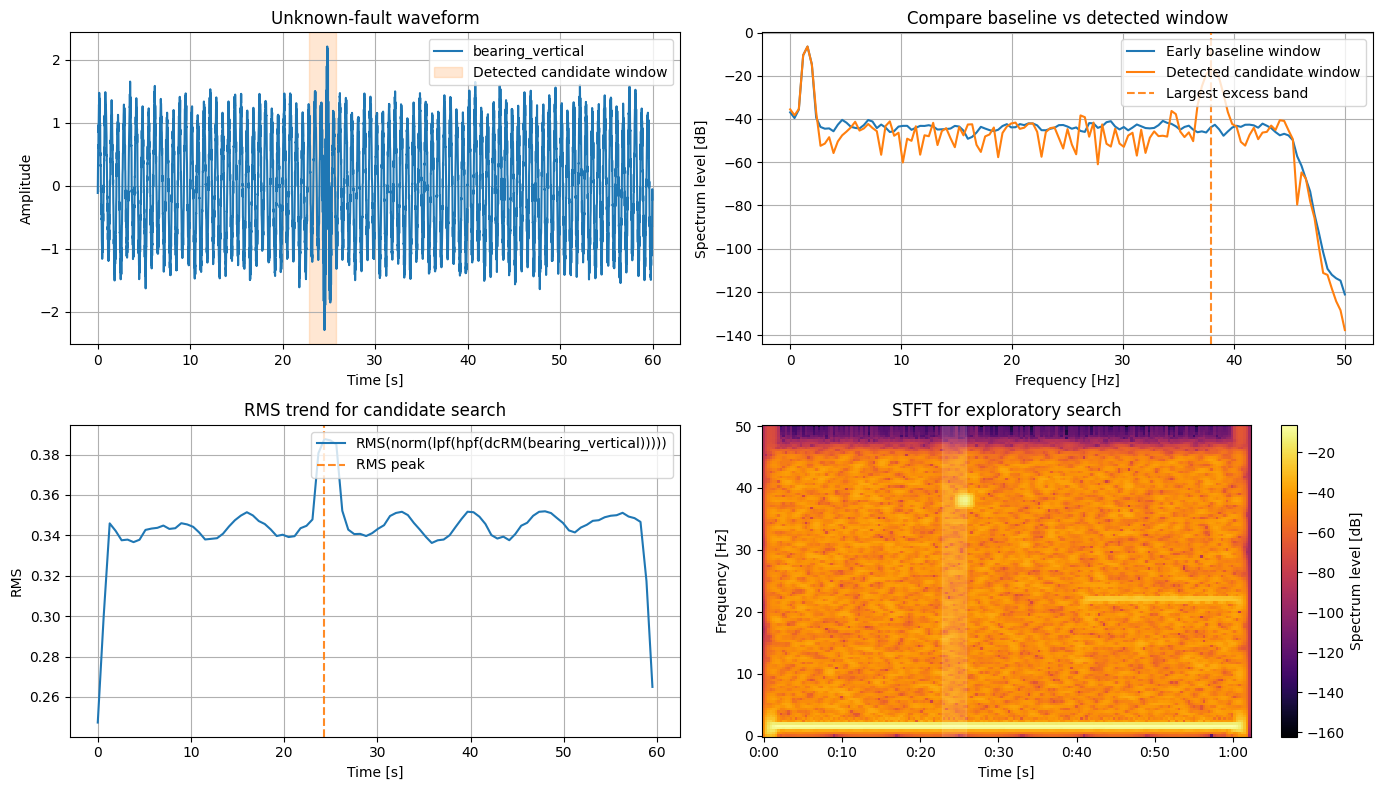

In [8]:
exploration_signal = (
    faulty_signal
    .remove_dc()
    .high_pass_filter(cutoff=1.0)
    .low_pass_filter(cutoff=45.0)
    .normalize()
)

exploration_trend = exploration_signal.rms_trend(frame_length=256, hop_length=64, dB=False)
exploration_trend_array = np.asarray(exploration_trend.compute().data).reshape(-1)
exploration_times = np.arange(exploration_trend_array.size) / exploration_trend.sampling_rate

candidate_idx = int(exploration_trend_array.argmax())
candidate_center = exploration_times[candidate_idx]
candidate_start = max(0.0, candidate_center - 1.5)
candidate_end = min(faulty_signal.duration, candidate_center + 1.5)

reference_window = exploration_signal.trim(start=0.0, end=12.0)
candidate_window = exploration_signal.trim(start=candidate_start, end=candidate_end)

reference_window_psd = reference_window.welch(n_fft=256, hop_length=64)
candidate_window_psd = candidate_window.welch(n_fft=256, hop_length=64)
exploration_spec = exploration_signal.stft(n_fft=256, hop_length=32, window='hann')

reference_window_psd_array = np.asarray(reference_window_psd.compute().data).reshape(-1)
candidate_window_psd_array = np.asarray(candidate_window_psd.compute().data).reshape(-1)
exploration_freqs = reference_window_psd.freqs
peak_band_idx = int(np.argmax(candidate_window_psd_array - reference_window_psd_array))
peak_band_hz = float(exploration_freqs[peak_band_idx])

exploration_fig, exploration_axes = plt.subplots(2, 2, figsize=(14, 8))

faulty_signal.plot(
    ax=exploration_axes[0, 0],
    title='Unknown-fault waveform',
    overlay=True,
)
exploration_axes[0, 0].axvspan(
    candidate_start,
    candidate_end,
    color='tab:orange',
    alpha=0.18,
    label='Detected candidate window',
)
exploration_axes[0, 0].legend(loc='upper right')

exploration_trend.plot(
    ax=exploration_axes[1, 0],
    title='RMS trend for candidate search',
    overlay=True,
    ylabel='RMS',
)
exploration_axes[1, 0].axvline(
    candidate_center,
    color='tab:orange',
    linestyle='--',
    alpha=0.9,
    label='RMS peak',
)
exploration_axes[1, 0].legend(loc='upper right')

reference_window_psd.plot(
    ax=exploration_axes[0, 1],
    overlay=True,
    label='Early baseline window',
)
candidate_window_psd.plot(
    ax=exploration_axes[0, 1],
    overlay=True,
    label='Detected candidate window',
    title='Compare baseline vs detected window',
)
exploration_axes[0, 1].axvline(
    peak_band_hz,
    color='tab:orange',
    linestyle='--',
    alpha=0.9,
    label='Largest excess band',
)
exploration_axes[0, 1].legend(loc='upper right')

exploration_spec.plot(
    ax=exploration_axes[1, 1],
    cmap='inferno',
    title='STFT for exploratory search',
)
exploration_axes[1, 1].axvspan(candidate_start, candidate_end, color='white', alpha=0.12)

plt.tight_layout()

candidate_window_seconds = (float(round(candidate_start, 2)), float(round(candidate_end, 2)))

print('Detected candidate center [s]:', float(round(candidate_center, 2)))
print('Detected candidate window [s]:', candidate_window_seconds)
print('Largest excess band [Hz]:', float(round(peak_band_hz, 2)))
print('Exploratory workflow: trend scan -> candidate trim -> spectral comparison -> STFT check')

assert candidate_center >= fault_start - 1.5
assert candidate_center <= fault_end + 1.5
assert peak_band_hz >= 35.0
assert peak_band_hz <= 40.5

## Conclusion
If all assertions passed, the current repository implementation is consistent with the documented wandas skills for the covered APIs.

The combined scenarios show two useful operating modes:
- a known-fault validation flow, where you confirm that the injected issue is visible where expected
- an exploratory flow, where you first detect a suspicious time window and only then inspect its spectral signature

In short, the skills are not only individually valid, but also compose into a practical workflow for making hidden signal issues visible.